In [2]:
import pandas as pd

df = pd.read_csv('Campaign report.csv', skiprows=2)
print(df.shape)
df.head()

(6, 23)


,Campaign status,Campaign,Budget,Budget name,Budget type,Status,Status reasons,Optimization score,Campaign type,Currency code,...,Interactions,Interaction rate,Avg. cost,Cost,Conv. (Platform Comparable),Cost / Conv. (Platform Comparable),Conv. value / Cost (Platform Comparable),Conv. rate,Conversions,Cost / conv.
0,Enabled,Video views - 2025-07-19,5000.00,--,Campaign Total,Ended,campaign ended; unknown,--,Video,INR,...,"20,127",77.77%,0.08,1661.67,0.0,0.00,0.00,0.00%,0.0,0.00
1,Enabled,MH-m-sand,500.00,--,Daily,Not eligible,All ad groups paused; All ads paused; most ads...,--,Demand Gen,INR,...,"1,934",9.53%,0.47,904.26,15.0,60.28,0.02,0.78%,15.0,60.28
2,Total: Campaigns,--,--,--,--,--,NaN,--,--,INR,...,"22,061",47.78%,0.12,2565.92,15.0,171.06,0.01,0.07%,15.0,171.06
3,Total: Account,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INR,...,"22,061",47.78%,0.12,2565.92,15.0,171.06,0.01,0.07%,15.0,171.06
4,Total: Video,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Video,INR,...,"20,127",77.77%,0.08,1661.67,0.0,0.00,0.00,0.00%,0.0,0.00


In [3]:
# Keep only real campaign rows
campaigns = df[df['Campaign'].isin([
    'Video views - 2025-07-19',
    'MH-m-sand'
])].copy()

# Clean numeric columns
def clean_num(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(',', '')
              .str.replace('%', '')
              .str.strip(),
        errors='coerce'
    )

campaigns['Impressions']  = clean_num(campaigns['Impr.'])
campaigns['Interactions'] = clean_num(campaigns['Interactions'])
campaigns['Cost']         = clean_num(campaigns['Cost'])
campaigns['Conversions']  = clean_num(campaigns['Conversions'])
campaigns['CPL']          = clean_num(campaigns['Cost / conv.'])
campaigns['CTR']          = clean_num(campaigns['Interaction rate'])
campaigns['CPM']          = clean_num(campaigns['Avg. CPM'])

print(campaigns[['Campaign','Impressions','Cost','Conversions','CPL','CTR']])

                   Campaign  Impressions     Cost  Conversions    CPL    CTR
0  Video views - 2025-07-19        25881  1661.67          0.0   0.00  77.77
1                 MH-m-sand        20287   904.26         15.0  60.28   9.53


In [4]:
# Export clean data for SQL analysis
campaigns.to_csv('campaigns_clean.csv', index=False)
print("Clean CSV saved! Download from Files panel on the left.")

Clean CSV saved! Download from Files panel on the left.


In [5]:
from google.colab import files
files.download('campaigns_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

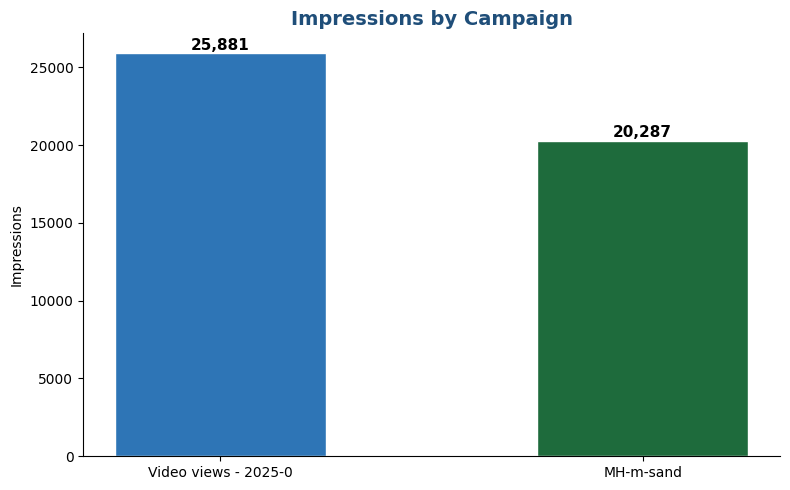

Chart 1 saved!


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2E75B6', '#1E6B3C']
bars = ax.bar(campaigns['Campaign'].str[:20],
              campaigns['Impressions'],
              color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, campaigns['Impressions']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{int(val):,}', ha='center', fontweight='bold', fontsize=11)

ax.set_title('Impressions by Campaign', fontsize=14, fontweight='bold', color='#1F4E79')
ax.set_ylabel('Impressions')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_impressions.png', dpi=150)
plt.show()
print("Chart 1 saved!")

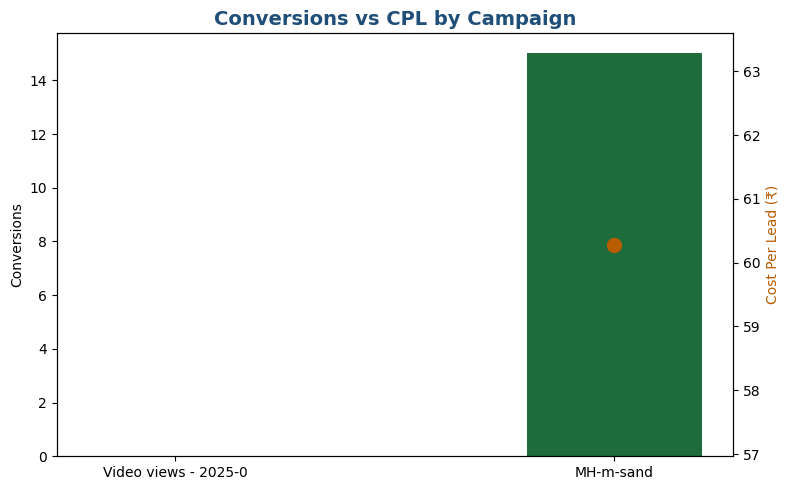

Chart 2 saved!


In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

bars = ax1.bar(campaigns['Campaign'].str[:20],
               campaigns['Conversions'],
               color=['#2E75B6', '#1E6B3C'], width=0.4, label='Conversions')
ax2.plot(campaigns['Campaign'].str[:20],
         campaigns['CPL'].replace(0, None),
         color='#B85C00', marker='o', linewidth=2,
         markersize=10, label='CPL (₹)')

ax1.set_ylabel('Conversions')
ax2.set_ylabel('Cost Per Lead (₹)', color='#B85C00')
ax1.set_title('Conversions vs CPL by Campaign', fontsize=14,
              fontweight='bold', color='#1F4E79')
plt.tight_layout()
plt.savefig('chart2_conversions_cpl.png', dpi=150)
plt.show()
print("Chart 2 saved!")

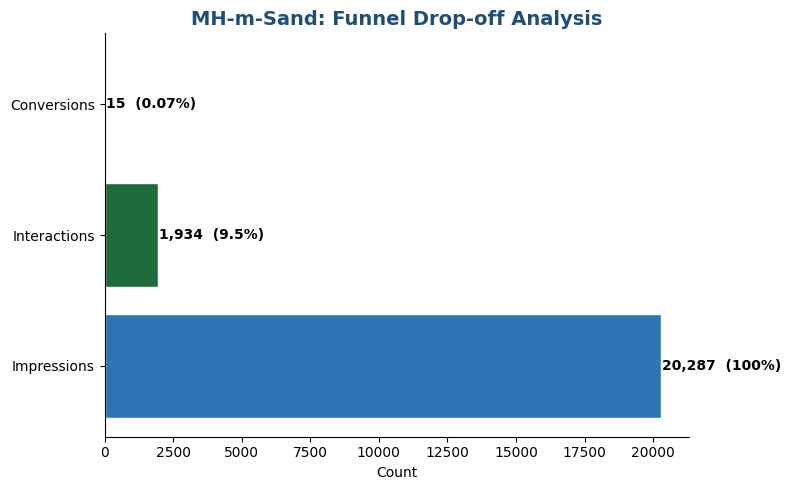

Chart 3 saved!


In [9]:
mh = campaigns[campaigns['Campaign'] == 'MH-m-sand'].iloc[0]

stages = ['Impressions', 'Interactions', 'Conversions']
values = [mh['Impressions'], mh['Interactions'], mh['Conversions']]
pcts   = [100, round(values[1]/values[0]*100,1), round(values[2]/values[0]*100,2)]

fig, ax = plt.subplots(figsize=(8, 5))
colors_f = ['#2E75B6', '#1E6B3C', '#B85C00']
bars = ax.barh(stages, values, color=colors_f, edgecolor='white')

for bar, val, pct in zip(bars, values, pcts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}  ({pct}%)', va='center', fontweight='bold')

ax.set_title('MH-m-Sand: Funnel Drop-off Analysis', fontsize=14,
             fontweight='bold', color='#1F4E79')
ax.set_xlabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_funnel.png', dpi=150)
plt.show()
print("Chart 3 saved!")

In [10]:
def calculate_metrics(row):
    metrics = {}
    metrics['campaign']    = row['Campaign']
    metrics['impressions'] = int(row['Impressions'])
    metrics['spend']       = round(row['Cost'], 2)
    metrics['conversions'] = int(row['Conversions'])
    metrics['cpl']         = round(row['CPL'], 2) if row['Conversions'] > 0 else None
    metrics['ctr']         = round(row['CTR'], 2)
    metrics['cpm']         = round(row['CPM'], 2)
    return metrics

def score_campaign(metrics):
    c   = metrics['conversions']
    cpl = metrics['cpl']
    ctr = metrics['ctr']

    if c > 0 and cpl and cpl < 150:
        return 'SCALE ✅', 'CPL well below benchmark. Increase budget immediately.'
    elif c > 0 and cpl and cpl < 300:
        return 'OPTIMIZE 🔧', 'Good CPL but room to improve. Test new creatives.'
    elif c == 0 and ctr > 50:
        return 'MONITOR 👀', 'Strong engagement but no conversions. Add conversion tracking.'
    elif c == 0 and ctr < 10:
        return 'PAUSE ⛔', 'Low engagement and no conversions. Review targeting.'
    else:
        return 'REVIEW 🔍', 'Mixed signals. Needs deeper analysis.'

# Run scoring
print("=" * 60)
print("CAMPAIGN ROI SCORECARD")
print("=" * 60)
for _, row in campaigns.iterrows():
    m = calculate_metrics(row)
    verdict, reason = score_campaign(m)
    print(f"\nCampaign: {m['campaign'][:30]}")
    print(f"  Impressions: {m['impressions']:,}")
    print(f"  Spend: ₹{m['spend']:,}")
    print(f"  Conversions: {m['conversions']}")
    print(f"  CPL: ₹{m['cpl']}" if m['cpl'] else "  CPL: N/A")
    print(f"  CTR: {m['ctr']}%")
    print(f"  VERDICT: {verdict}")
    print(f"  REASON: {reason}")
print("\n" + "=" * 60)

CAMPAIGN ROI SCORECARD

Campaign: Video views - 2025-07-19
  Impressions: 25,881
  Spend: ₹1,661.67
  Conversions: 0
  CPL: N/A
  CTR: 77.77%
  VERDICT: MONITOR 👀
  REASON: Strong engagement but no conversions. Add conversion tracking.

Campaign: MH-m-sand
  Impressions: 20,287
  Spend: ₹904.26
  Conversions: 15
  CPL: ₹60.28
  CTR: 9.53%
  VERDICT: SCALE ✅
  REASON: CPL well below benchmark. Increase budget immediately.



In [11]:
def generate_report(df, campaigns_df):
    total_spend = campaigns_df['Cost'].sum()
    total_conv  = campaigns_df['Conversions'].sum()
    blended_cpl = round(total_spend / total_conv, 2) if total_conv > 0 else None

    print("\n📊 CAMPAIGN PERFORMANCE REPORT")
    print(f"Total Campaigns: {len(campaigns_df)}")
    print(f"Total Impressions: {int(campaigns_df['Impressions'].sum()):,}")
    print(f"Total Spend: ₹{total_spend:,.2f}")
    print(f"Total Conversions: {int(total_conv)}")
    print(f"Blended CPL: ₹{blended_cpl}" if blended_cpl else "Blended CPL: N/A")
    print("\nRECOMMENDATIONS:")
    for _, row in campaigns_df.iterrows():
        m = calculate_metrics(row)
        verdict, reason = score_campaign(m)
        print(f"  → {m['campaign'][:25]}: {verdict}")
    print("\nReport complete! ✅")

# Run it
generate_report(df, campaigns)


📊 CAMPAIGN PERFORMANCE REPORT
Total Campaigns: 2
Total Impressions: 46,168
Total Spend: ₹2,565.93
Total Conversions: 15
Blended CPL: ₹171.06

RECOMMENDATIONS:
  → Video views - 2025-07-19: MONITOR 👀
  → MH-m-sand: SCALE ✅

Report complete! ✅
